<a href="https://colab.research.google.com/github/TramSt/decision-tree-pima-diabetes/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Thư viện

In [ ]:
import pandas as pd
import numpy as np

In [27]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [7]:

!rm -rf decision-tree-pima-diabetes
!git clone https://github.com/TramSt/decision-tree-pima-diabetes.git
%cd decision-tree-pima-diabetes
!ls


Cloning into 'decision-tree-pima-diabetes'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 49 (delta 14), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 24.26 KiB | 12.13 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/decision-tree-pima-diabetes
data  notebooks  README.md  slides


In [8]:
!ls data

diabetes.csv


# 2. Read data EDA

In [ ]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

In [10]:
df = pd.read_csv("data/diabetes.csv")
df.head()



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
print(f'Bộ dữ liệu có {df.shape[0]} dòng và {df.shape[1]} cột')


Bộ dữ liệu có 768 dòng và 9 cột


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
(df == 0).sum()
# Glucose, BloodPressure, BMI có giá trị = 0 là không hợp lý về mặt y học
# → xem như missing values
# → cần xử lý ở bước preprocessing

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


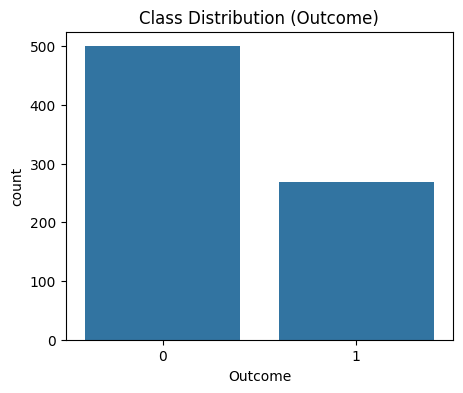

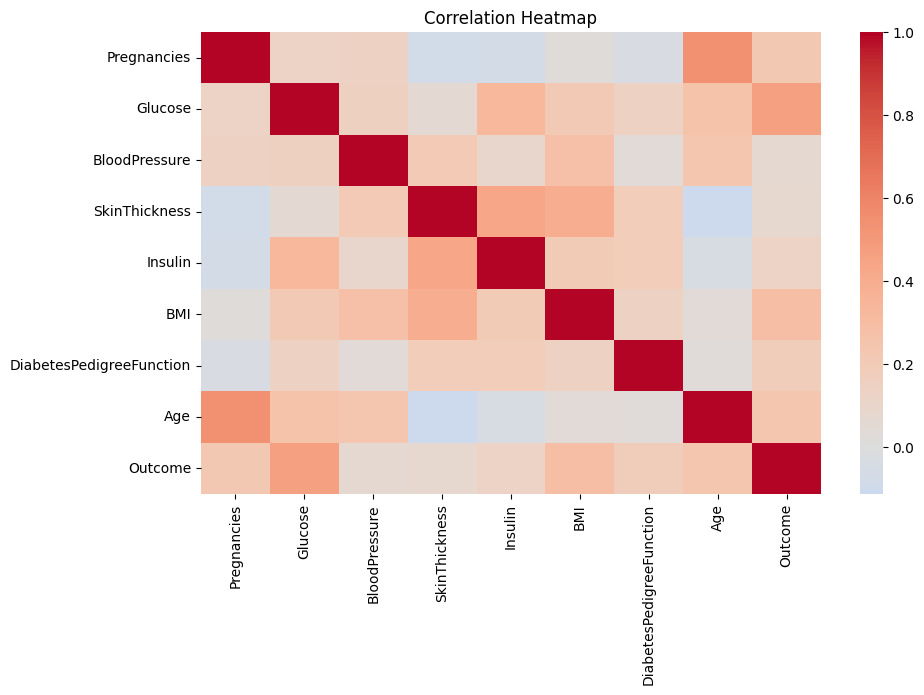

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution (Outcome)")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [22]:
#missing value
df_clean = df.copy()

invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

df_clean[invalid_zero_cols].isna().sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [21]:
#Train/Test split
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


In [24]:
#Pipeline preprocessing (imputer + scaler)
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [28]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    print("===", title, "===")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    if y_prob is not None:
        print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

    print("\nClassification report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"ROC Curve - {title}")
        plt.show()

=== Logistic Regression (baseline) ===
Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1-score : 0.5454545454545454
ROC-AUC  : 0.812962962962963

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



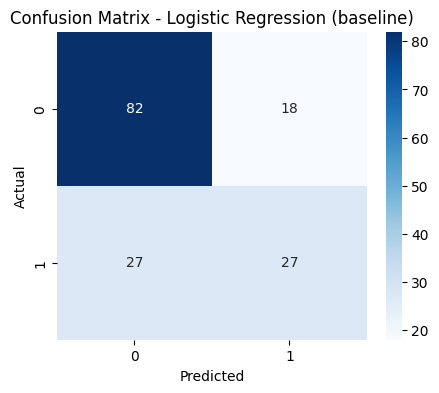

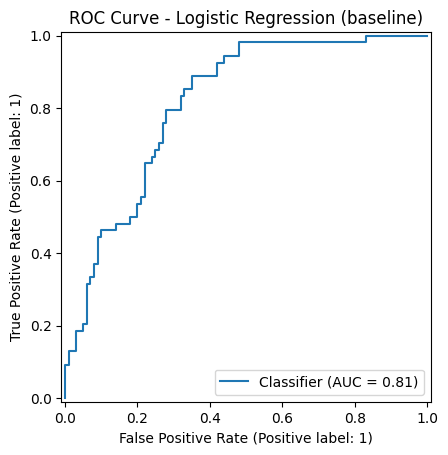

In [38]:
logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

logreg.fit(X_train, y_train)
evaluate_model(logreg, X_test, y_test, "Logistic Regression (baseline)")


=== Random Forest ===
Accuracy : 0.7532467532467533
Precision: 0.6739130434782609
Recall   : 0.5740740740740741
F1-score : 0.62
ROC-AUC  : 0.8202777777777777

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



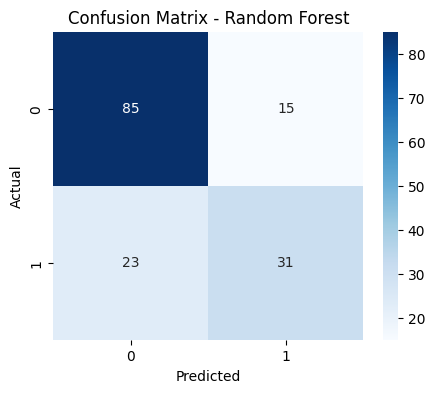

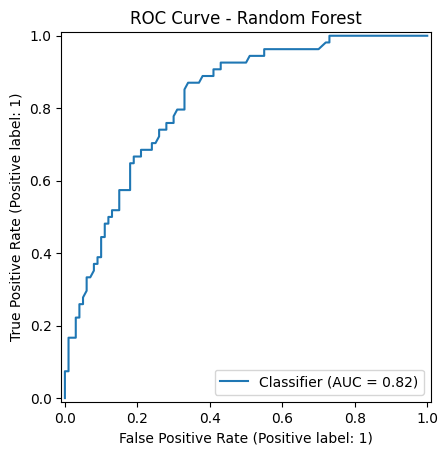

=== SVM (RBF) ===
Accuracy : 0.7272727272727273
Precision: 0.5909090909090909
Recall   : 0.7222222222222222
F1-score : 0.65
ROC-AUC  : 0.8138888888888889

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



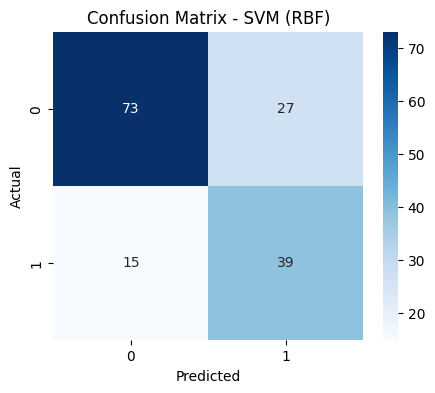

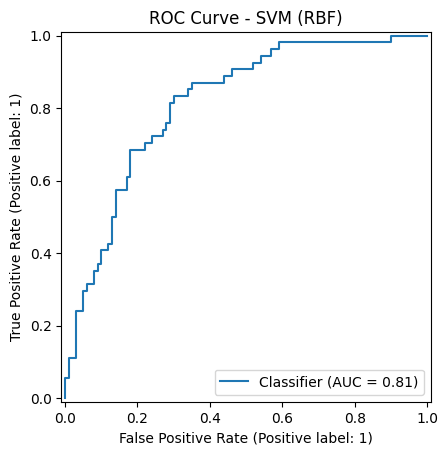

In [35]:
rf = Pipeline(steps=[
    ("preprocess", preprocess),   # RF không bắt buộc scale nhưng giữ pipeline đồng nhất
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced"  # giúp cải thiện recall khi lệch lớp
    ))
])

svm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
])

rf.fit(X_train, y_train)
svm.fit(X_train, y_train)

evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(svm, X_test, y_test, "SVM (RBF)")

In [36]:
def quick_scores(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

rows = [
    quick_scores(logreg, X_test, y_test, "LogReg"),
    quick_scores(rf, X_test, y_test, "RF"),
    quick_scores(svm, X_test, y_test, "SVM")
]
pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,RF,0.753247,0.673913,0.574074,0.620000,0.820278
2,SVM,0.727273,0.590909,0.722222,0.650000,0.813889
0,LogReg,0.707792,0.600000,0.500000,0.545455,0.812963


In [39]:

best = logreg  # hoặc rf / svm tùy model tốt nhất
y_prob = best.predict_proba(X_test)[:,1]

prec, rec, thr = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision/Recall vs Threshold")
plt.show()

# Ví dụ chọn threshold để Recall >= 0.80 (tùy mục tiêu)
target_recall = 0.80
idx = np.where(rec[:-1] >= target_recall)[0]
if len(idx) > 0:
    chosen_thr = thr[idx[-1]]
    print("Chosen threshold:", chosen_thr)
else:
    chosen_thr = 0.5
    print("Cannot reach target recall, fallback 0.5")

y_pred_thr = (y_prob >= chosen_thr).astype(int)
print("Recall:", recall_score(y_test, y_pred_thr))
print("Precision:", precision_score(y_test, y_pred_thr))
print("F1:", f1_score(y_test, y_pred_thr))


NameError: name 'precision_recall_curve' is not defined

In [40]:
pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=3000))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

grid = GridSearchCV(
    pipe_lr, param_grid=param_grid,
    scoring="roc_auc", cv=5, n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_lr = grid.best_estimator_
evaluate_model(best_lr, X_test, y_test, "Tuned Logistic Regression")

NameError: name 'GridSearchCV' is not defined

In [ ]:
feature_names = X.columns
coef = best_lr.named_steps["model"].coef_[0]
imp_lr = pd.Series(coef, index=feature_names).sort_values()

plt.figure(figsize=(7,4))
imp_lr.plot(kind="barh")
plt.title("Logistic Regression Coefficients")
plt.show()